snippets.py

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Визуализация сниппетов
def plot_snippets(ts, snippets):
    with plt.rc_context(
        {
            "lines.linewidth": 2,
            "font.size": 24,
        }
    ):
        fig, (ax_main, ax_labels) = plt.subplots(
            2, figsize=(16, 6), gridspec_kw={"height_ratios": [16, 2]}
        )
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        ax_main.plot(ts, color="gray")

        m = len(snippets[0][0])
        print(m)
        snippets_indices = snippets[1]
        for i, snippet_start in enumerate(snippets_indices):
            snippet_end = snippet_start + m
            ax_main.plot(
                np.arange(snippet_start, snippet_end),
                ts[snippet_start:snippet_end],
                c=color_cycle[i],
                label=f"Snippet {i}: {snippets[3][i]:.2f}",
            )

        labels = np.zeros_like(ts)
        snippets_regimes = snippets[5]
        for regime in snippets_regimes:
            labels[regime[1] : regime[2]] = regime[0]

        img = ax_labels.imshow([range(len(color_cycle))], cmap="tab10", aspect="auto")
        img.set_data([labels])

        ax_main.set_xlim(0, len(ts))
        ax_labels.axis("off")
        ax_main.legend(prop={"size": 16}, loc="upper right")
        plt.tight_layout()
        plt.show()
    return ax_main

# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

Импорт библиотек и модулей

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#from modules.snippets import *
from scipy import signal
from stumpy import snippets
import stumpy
from scipy import stats

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

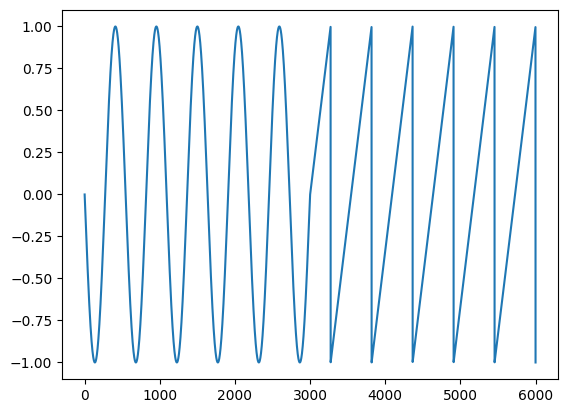

In [3]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [4]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


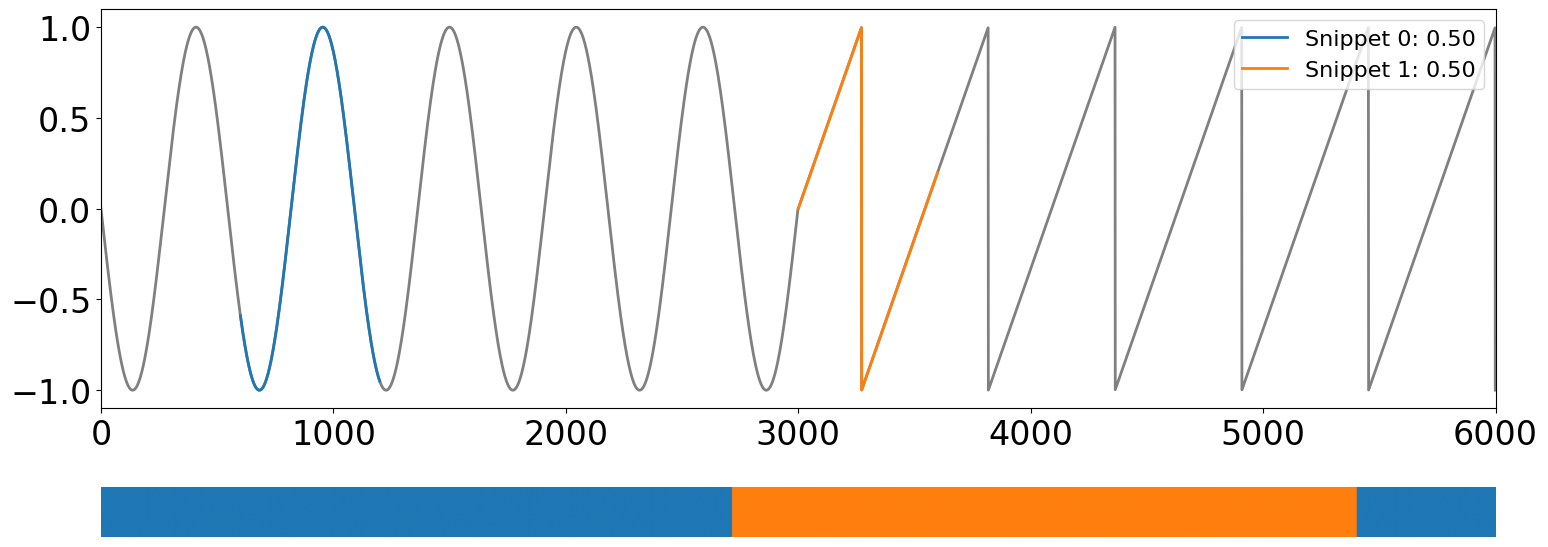

<Axes: >

In [5]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [6]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [7]:
ts_url = '/gdrive/My Drive/Colab Notebooks/АиПВРМИИ/05/PAMAP.txt' # для colab

In [8]:
test = np.loadtxt(ts_url)

In [9]:
test.shape

(20, 146000)

In [10]:
# Загрузим данные и транспонируем их
raw_data = np.loadtxt(ts_url)
transposed_data = raw_data.T

# Теперь выберем столбцы для времени (0), ID активности (1) и гироскопа Y (11)
data = transposed_data[:, [0, 1, 11]]

# Фильтруем данные за указанный временной интервал
time_interval_mask = (data[:, 0] >= 1790) & (data[:, 0] <= 1930)
ts = data[time_interval_mask, 2]
y_true = data[time_interval_mask, 1].astype(int)

# Установим длину фрагмента (размер окна)
m = 100

# Найдём k лучших фрагментов (в данном случае k=10)
k = 10
snippets = stumpy.snippets(ts, m, k)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

100


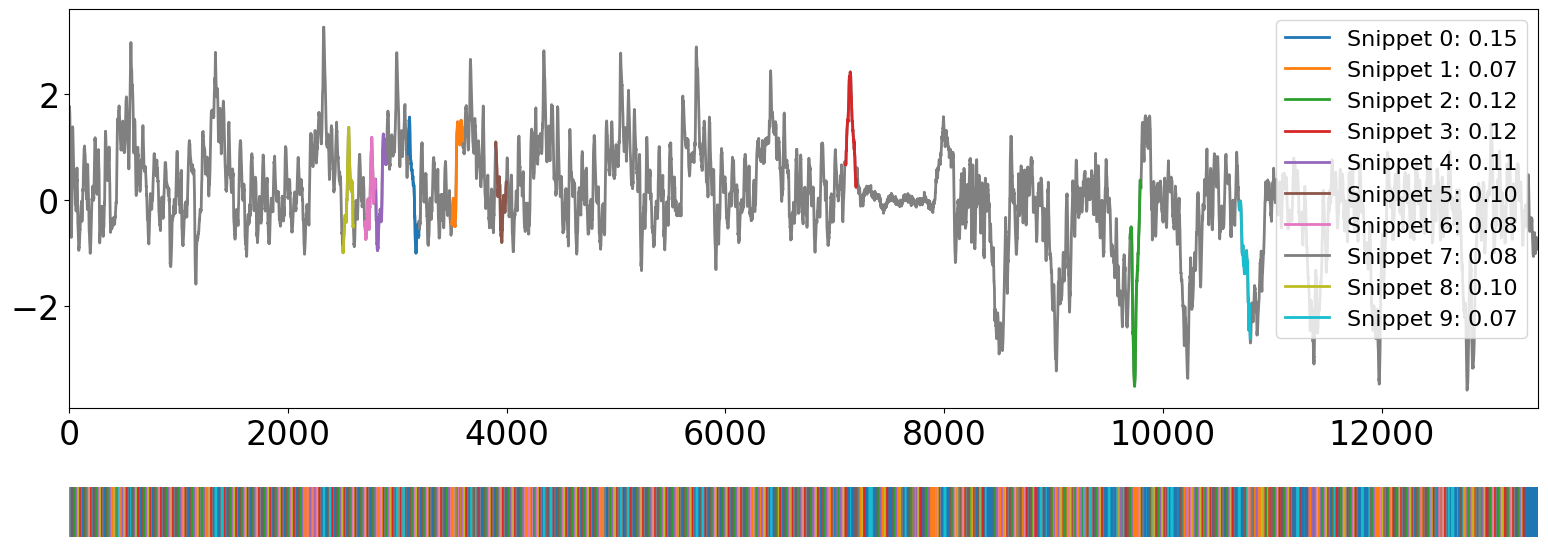

<Axes: >

In [11]:
# Визуализируем результат
plot_snippets(ts, snippets)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [12]:
# Define activity labels for better interpretation
ACTIVITY_MAP = {
    1: "lying", 2: "sitting", 3: "standing", 4: "walking", 5: "running",
    6: "cycling", 7: "Nordic walking", 9: "watching TV", 10: "computer work",
    11: "car driving", 12: "ascending stairs", 13: "descending stairs",
    16: "vacuum cleaning", 17: "ironing", 18: "folding laundry",
    19: "house cleaning", 20: "playing soccer", 24: "rope jumping",
    0: "other"
}

In [13]:
# Создаем массив предсказанных меток на основе фрагментов
# Используем -1 для неклассифицированных областей
y_pred = np.full(ts.shape[0], -1, dtype=int)
regimes = snippets[5]
for regime in regimes:
    snippet_idx, start, end = regime
    y_pred[start:end] = snippet_idx

# Определяем наилучшую привязку индексов фрагмента к истинному типу активности
snippet_activity_map = {}
for snippet_idx in range(k):
    # Находим все места, где этот фрагмент был определен
    mask = (y_pred == snippet_idx)
    if np.any(mask):
        # Находим наиболее частый истинный ярлык активности в этих местах
        most_common_activity = stats.mode(y_true[mask])[0]
        snippet_activity_map[snippet_idx] = most_common_activity

# Формируем новый массив предсказанных меток используя сопоставленные типы активности
y_pred_mapped = np.full(ts.shape[0], -1, dtype=int)
for snippet_idx, activity_id in snippet_activity_map.items():
    y_pred_mapped[y_pred == snippet_idx] = activity_id

# Вычисляем точность только на классифицированных областях
classified_mask = (y_pred != -1)
accuracy = np.mean(y_pred_mapped[classified_mask] == y_true[classified_mask])

# Результаы
print("Результаты анализа фрагментов")
print(f"Длина временного ряда: {len(ts)} точек")
print("\nПривязка индекса фрагмента к активности:")
for snippet_idx, activity_id in snippet_activity_map.items():
    activity_name = ACTIVITY_MAP.get(activity_id, "Неизвестно")
    print(f"  Фрагмент {snippet_idx} -> Активность '{activity_name}' (ID: {activity_id})")

print(f"\nТочность маркировки на основе фрагментов: {accuracy:.2%}")

Результаты анализа фрагментов
Длина временного ряда: 13430 точек

Привязка индекса фрагмента к активности:
  Фрагмент 0 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 1 -> Активность 'descending stairs' (ID: 13)
  Фрагмент 2 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 3 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 4 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 5 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 6 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 7 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 8 -> Активность 'ascending stairs' (ID: 12)
  Фрагмент 9 -> Активность 'descending stairs' (ID: 13)

Точность маркировки на основе фрагментов: 58.41%


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

В выбранном временном интервале активность "подъем по лестнице" является основной и занимает большую часть времени.

Сигнал во время подъема по лестнице настолько вариативен, что алгоритм нашел целых 8 различных, но часто повторяющихся паттернов. Это могут быть фазы шага, небольшие изменения в темпе, повороты на лестничной площадке и т.д.

Цифра 58.41% говорит нам о том, что примерно 58.4% всего временного ряда (в рассматриваемом интервале) действительно является активностью "подъем по лестнице" или "спуск по лестнице".

Оставшаяся погрешность (~42%), скорее всего, связана с переходными процессами между активностями, моментами отдыха или участками сигнала, которые не похожи ни на один из 10 найденных эталонных паттернов.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [14]:
# Константы для анализа
ts_url = '/gdrive/My Drive/Colab Notebooks/АиПВРМИИ/05/PAMAP.txt'
k = 10  # Количество сниппетов для поиска (как в успешном эксперименте)
m = 100 # Длина сниппета (размер окна)
gyro_cols = [10, 11, 12] # Колонки для гироскопов X, Y, Z

# Словарь для сопоставления ID активностей их названиям
ACTIVITY_MAP = {
    1: "lying", 2: "sitting", 3: "standing", 4: "walking", 5: "running",
    6: "cycling", 7: "Nordic walking", 9: "watching TV", 10: "computer work",
    11: "car driving", 12: "ascending stairs", 13: "descending stairs",
    16: "vacuum cleaning", 17: "ironing", 18: "folding laundry",
    19: "house cleaning", 20: "playing soccer", 24: "rope jumping",
    0: "other"
}

# Загрузка и предобработка данных
raw_data = np.loadtxt(ts_url)
transposed_data = raw_data.T

# Выбираем колонки: время, ID активности и три оси гироскопа
all_cols = [0, 1] + gyro_cols
data = transposed_data[:, all_cols]

# Фильтруем данные по заданному временному интервалу
time_interval_mask = (data[:, 0] >= 1790) & (data[:, 0] <= 1930)

# Извлекаем истинные метки и многомерный временной ряд
y_true = data[time_interval_mask, 1].astype(int)
ts_multivariate = data[time_interval_mask, 2:] # Срез, начиная с первой колонки гироскопа

# Поиск сниппетов для каждой оси
all_predictions = []
for i in range(ts_multivariate.shape[1]):
    ts_univariate = ts_multivariate[:, i]
    snippets = stumpy.snippets(ts_univariate, m, k)

    # Создаем массив с предсказанными метками для данной оси
    y_pred_axis = np.full(ts_univariate.shape[0], -1, dtype=int)
    regimes = snippets[5]
    for snippet_idx, start, end in regimes:
        y_pred_axis[start:end] = snippet_idx
    all_predictions.append(y_pred_axis)

# Объединение результатов голосованием большинством
# Помещаем предсказания в единый массив (стек)
predictions_stack = np.stack(all_predictions, axis=0)

# Для каждой временной точки (колонки) находим наиболее частую метку (моду)
y_pred_voted = stats.mode(predictions_stack, axis=0, keepdims=True)[0].flatten()

# Оценка точности объединенной разметки
# Находим лучшее соответствие между итоговым индексом сниппета и ID реальной активности
voted_snippet_activity_map = {}
unique_voted_labels = np.unique(y_pred_voted[y_pred_voted != -1])

for snippet_idx in unique_voted_labels:
    mask = (y_pred_voted == snippet_idx)
    if np.any(mask):
        most_common_activity = stats.mode(y_true[mask], keepdims=True)[0][0]
        voted_snippet_activity_map[snippet_idx] = most_common_activity

# Создаем финальный массив предсказанных ID активностей
y_pred_mapped = np.full(y_true.shape[0], -1, dtype=int)
for snippet_idx, activity_id in voted_snippet_activity_map.items():
    y_pred_mapped[y_pred_voted == snippet_idx] = activity_id

# Считаем точность только для тех участков, которые были размечены
classified_mask = (y_pred_voted != -1)
accuracy = np.mean(y_pred_mapped[classified_mask] == y_true[classified_mask])

# Вывод результатов
print("\nРезультаты анализа многомерного временного ряда")
print(f"Проанализировано {ts_multivariate.shape[1]} оси гироскопа (X, Y, Z)")
print(f"Длина временного ряда: {y_true.shape[0]} точек")

print("\nСоответствие итогового индекса сниппета и активности:")
for snippet_idx in sorted(voted_snippet_activity_map.keys()):
  activity_id = voted_snippet_activity_map[snippet_idx]
  activity_name = ACTIVITY_MAP.get(activity_id, "Unknown")
  print(f"  Фрагмент {snippet_idx} -> Активность '{activity_name}' (ID: {activity_id})")

print(f"\nИтоговая точность (многомерное голосование): {accuracy:.2%}")



Результаты анализа многомерного временного ряда
Проанализировано 3 оси гироскопа (X, Y, Z)
Длина временного ряда: 13430 точек

Соответствие итогового индекса сниппета и активности:
  Итоговый сниппет 0 -> Активность 'ascending stairs' (ID: 12)
  Итоговый сниппет 1 -> Активность 'ascending stairs' (ID: 12)
  Итоговый сниппет 2 -> Активность 'descending stairs' (ID: 13)
  Итоговый сниппет 3 -> Активность 'ascending stairs' (ID: 12)
  Итоговый сниппет 4 -> Активность 'ascending stairs' (ID: 12)
  Итоговый сниппет 5 -> Активность 'ascending stairs' (ID: 12)
  Итоговый сниппет 6 -> Активность 'descending stairs' (ID: 13)
  Итоговый сниппет 7 -> Активность 'ascending stairs' (ID: 12)
  Итоговый сниппет 8 -> Активность 'ascending stairs' (ID: 12)
  Итоговый сниппет 9 -> Активность 'ascending stairs' (ID: 12)

Итоговая точность (многомерное голосование): 57.64%


100


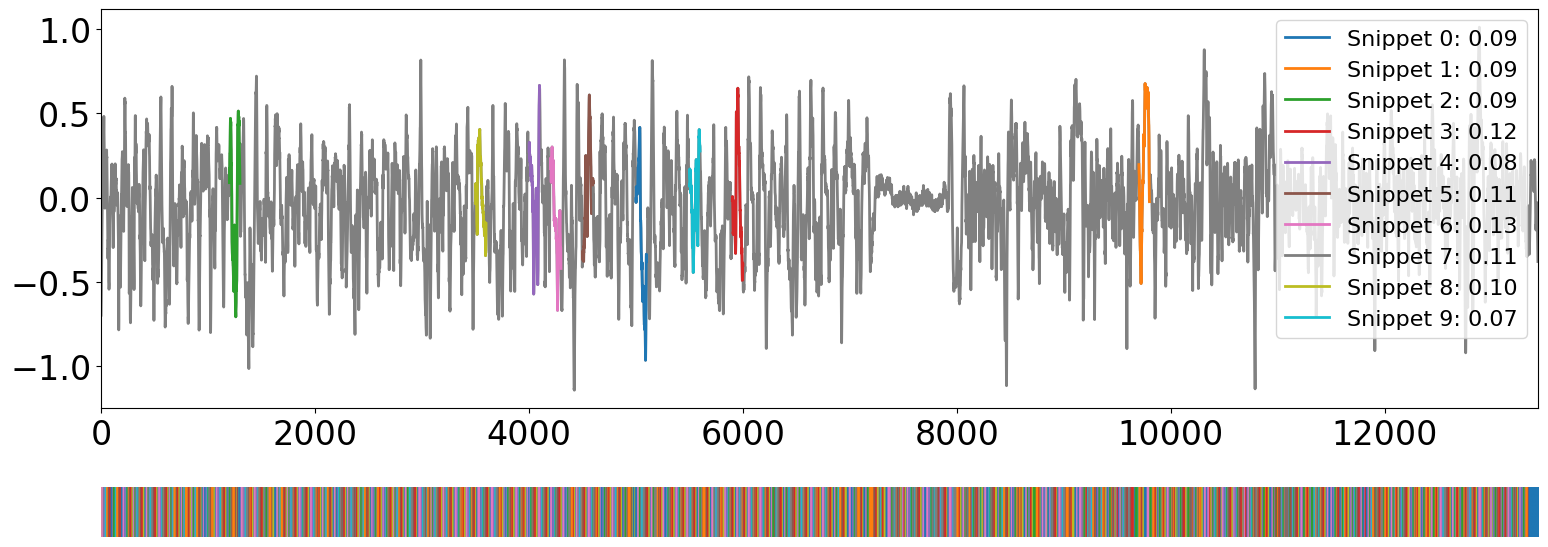

<Axes: >

In [15]:
# Визуализируем результат
plot_snippets(ts_univariate, snippets)

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Как и в одномерном анализе с k=10, многомерный подход также выделил две основные активности: 'ascending stairs' (подъем по лестнице) и 'descending stairs' (спуск по лестнице).

Распределение сниппетов очень похоже на предыдущий результат. 8 из 10 итоговых "усредненных" сниппетов были сопоставлены с подъемом, и 2 — со спуском. Это подтверждает, что даже при анализе всех трех осей гироскопа, общая картина движений остается прежней: доминирующий и сложный подъем по лестнице и менее частый спуск.

Основной результат чрезвычайно стабилен. Независимо от того, анализируем ли мы одну, самую информативную ось (Y, угол тангажа), или все три оси вместе, алгоритм приходит к одному и тому же заключению о составе движений в данном временном интервале. Это говорит о том, что сигнал от подъема и спуска по лестнице очень четкий и характерный.

Точность многомерного анализа оказалась немного ниже, чем у одномерного. Вероятно, для задачи различения подъема и спуска по лестнице ось Y (тангаж, наклон вперед-назад) является наиболее информативной. Оси X и Z  могут содержать менее полезную информацию или даже "шум". В ситуациях, когда одна ось дает очень четкий сигнал, а две другие — неоднозначный, "голоса" от менее информативных осей могут "перебить" правильное решение от главной оси.


## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [19]:
import numpy as np
import stumpy
import matplotlib.pyplot as plt

# Константы
ts_url = '/gdrive/My Drive/Colab Notebooks/АиПВРМИИ/05/PAMAP.txt'
m = 100 # Длина сниппета
k_values = range(1, 10) # k будет меняться от 1 до 9


# Загрузка данных (используем ось Y гироскопа)
raw_data = np.loadtxt(ts_url)
transposed_data = raw_data.T
data = transposed_data[:, [0, 11]] # Время и ось Y гироскопа
time_interval_mask = (data[:, 0] >= 1790) & (data[:, 0] <= 1930)
ts = data[time_interval_mask, 1]

# Вычисление Profile Area для каждого k
profile_areas = {}
for k in k_values:
    snippets_data = stumpy.snippets(ts, m, k)

    # Получаем список всех профилей расстояний
    distance_profiles = snippets_data[3]

    # Находим итоговый профиль как поэлементный минимум
    # Преобразуем список массивов в 2D-массив для min(axis=0)
    final_profile = np.min(np.array(distance_profiles), axis=0)

    # Суммируем итоговый профиль для получения площади
    profile_areas[k] = np.sum(final_profile)
    print(f"  k={k}, Profile Area = {profile_areas[k]:.2f}")

# Вычисление меры Change для каждого k
changes = {}
for k in range(2, 10):
    pa_k_minus_1 = profile_areas[k-1]
    pa_k = profile_areas[k]
    # Используем формулу: Change_k = (PA_{k-1} / PA_k) - 1
    changes[k] = (pa_k_minus_1 / pa_k) - 1
    print(f"  k={k}, Change = {changes[k]:.4f}")




  k=1, Profile Area = 1.00
  k=2, Profile Area = 0.49
  k=3, Profile Area = 0.23
  k=4, Profile Area = 0.21
  k=5, Profile Area = 0.16
  k=6, Profile Area = 0.12
  k=7, Profile Area = 0.11
  k=8, Profile Area = 0.09
  k=9, Profile Area = 0.07
  k=2, Change = 1.0579
  k=3, Change = 1.0924
  k=4, Change = 0.0940
  k=5, Change = 0.3691
  k=6, Change = 0.2799
  k=7, Change = 0.0994
  k=8, Change = 0.2221
  k=9, Change = 0.3536


Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

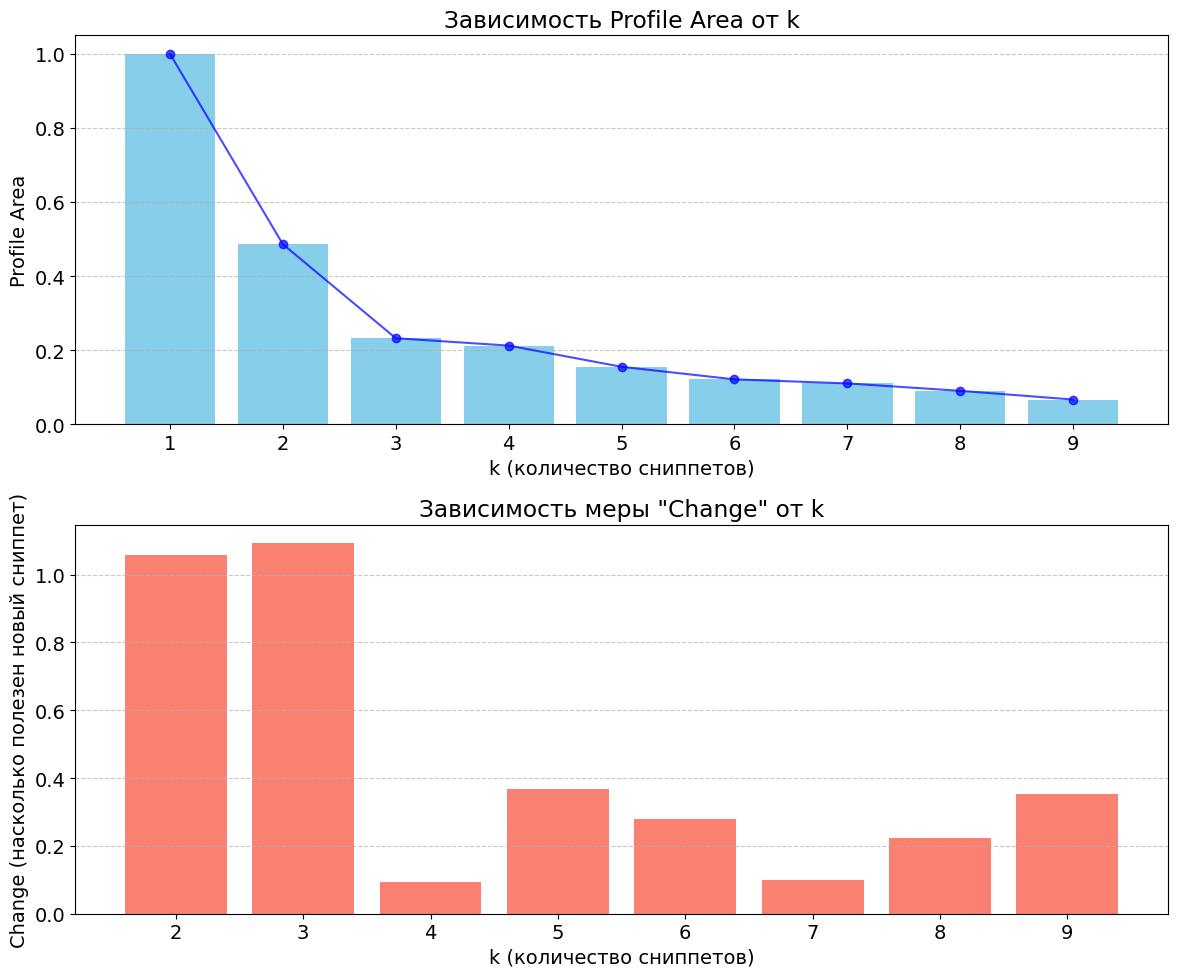

In [21]:
with plt.rc_context({"font.size": 14}):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # График Profile Area от k
    k_pa = list(profile_areas.keys())
    areas = list(profile_areas.values())
    ax1.bar(k_pa, areas, color='skyblue')
    ax1.plot(k_pa, areas, 'o-', color='blue', alpha=0.7)
    ax1.set_title('Зависимость Profile Area от k')
    ax1.set_ylabel('Profile Area')
    ax1.set_xlabel('k (количество сниппетов)')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.set_xticks(k_pa)

    # График Change от k
    k_ch = list(changes.keys())
    change_values = list(changes.values())
    ax2.bar(k_ch, change_values, color='salmon')
    ax2.set_title('Зависимость меры "Change" от k')
    ax2.set_ylabel('Change (насколько полезен новый сниппет)')
    ax2.set_xlabel('k (количество сниппетов)')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.set_xticks(k_ch)

    fig.tight_layout()
    plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?

Один-единственный сниппет описывает данные очень плохо. Profile Area максимальна (здесь она нормирована к 1.0). Это наша отправная точка.

Добавление второго сниппета вызывает драматическое улучшение. Profile Area падает более чем в два раза (с 1.0 до 0.49). Это говорит о том, что в данных есть как минимум два очень разных, но очень распространенных типа паттернов.

Добавление третьего сниппета снова дает очень существенное улучшение (с 0.49 до 0.23). Это значит, что существует и третий важный, типичный паттерн, который не был похож на первые два.

После k=3 кривая начинает выравниваться. Уменьшение Profile Area становится гораздо менее выраженным.

Мы видим два огромных пика, Change при k=2 и k=3 имеет значения больше 1.0. Это означает, что добавление второго и третьего сниппетов принесло колоссальную пользу, уменьшив ошибку более чем вдвое на каждом шаге. Это самые важные и информативные сниппеты.